In [37]:
import os
import re
import cv2
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Define your exact project paths
ROOT = Path("C:\\Users\\rik_y\\Documents\\GitHub\\ricardoserrano.github.io\\Carcassone_Companion_App\\tile_library_z-man_2014")
IMAGE_SOURCE = ROOT / "crops_training_set"
MASK_SOURCE = ROOT / "Segmentation_mask_09142026/SegmentationClass_touched_up"

class CarcassonneSplitDataset(Dataset):
    def __init__(self, file_list, images_dir, masks_dir, target_size=(256, 256)):
        """
        Accepts an explicit list of filenames to construct the split.
        """
        self.valid_images = file_list
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.target_size = target_size
        self.image_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.image_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        
        # OpenCV reads BGR. This mapping is flipped to (Blue, Green, Red)
        self.bgr_to_id = {
            (0, 0, 0): 0,       # Background / background
            (80, 80, 178): 1,   # City
            (255, 221, 51): 2,  # Farm
            (61, 245, 61): 3,   # Field
            (103, 157, 250): 4, # Garden
            (83, 50, 250): 5,   # Monastery
            (209, 240, 170): 6, # Road
            (183, 50, 250): 7,  # RoadBlock
            (23, 102, 169): 8   # Shield
        }

    def _bgr_to_class_mask(self, mask_bgr):
        height, width, _ = mask_bgr.shape
        class_mask = np.zeros((height, width), dtype=np.int64)

        for bgr, class_id in self.bgr_to_id.items():
            match_condition = np.all(
                mask_bgr == np.array(bgr, dtype=np.uint8),
                axis=2
            )
            class_mask[match_condition] = class_id

        return class_mask

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_name = self.valid_images[idx]
        img_path = self.images_dir / img_name
        mask_name = img_path.stem + ".png"
        mask_path = self.masks_dir / mask_name
        
        image = cv2.imread(str(img_path))
        mask = cv2.imread(str(mask_path))
        
        image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        class_mask = self._bgr_to_class_mask(mask)
        
        image_tensor = torch.from_numpy(image_rgb).permute(2, 0, 1).float() / 255.0
        image_tensor = (image_tensor - self.image_mean) / self.image_std
        mask_tensor = torch.from_numpy(class_mask).long()
        
        return image_tensor, mask_tensor

# --- Step 1: Discover all matching files first ---
filename_regex = re.compile(r'^IMG_\d+\.(jpg|jpeg)$', re.IGNORECASE)
all_images = sorted([
    f.name for f in IMAGE_SOURCE.iterdir() 
    if f.is_file() and filename_regex.match(f.name)
])

# --- Step 2: Split filenames (80% Train, 20% Validation) ---
# random_state keeps the split reproducible across script runs
train_files, val_files = train_test_split(all_images, test_size=0.2, random_state=42)

print(f"Total matching images found: {len(all_images)}")
print(f"Allocated {len(train_files)} to training and {len(val_files)} to validation.")

# --- Step 3: Instantiate Dataset objects ---
train_dataset = CarcassonneSplitDataset(train_files, IMAGE_SOURCE, MASK_SOURCE)
val_dataset = CarcassonneSplitDataset(val_files, IMAGE_SOURCE, MASK_SOURCE)

# --- Step 4: Create DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)


Total matching images found: 16
Allocated 12 to training and 4 to validation.


In [38]:
# Highly recommended for Carcassonne: give higher weight to rare elements like Shields and RoadBlocks
# These weights tell the loss function to care more about small features.
# Layout: [Background, City, Farm, Field, Garden, Monastery, Road, RoadBlock, Shield]
# class_weights = torch.tensor([1.0, 2.0, 1.5, 1.2, 3.0, 4.0, 3.0, 5.0, 5.0]).cuda() 

# Note: Remove .cuda() if you are training purely on a laptop CPU:
class_weights = torch.tensor([1.0, 2.0, 1.5, 1.2, 3.0, 4.0, 3.0, 5.0, 5.0])

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)


In [39]:
import torch
import torch.optim as optim
from transformers import SegformerForSemanticSegmentation

id2label = {
    0: "Background", 1: "City", 2: "Farm", 3: "Field", 
    4: "Garden", 5: "Monastery", 6: "Road", 7: "RoadBlock", 8: "Shield"
}

# 1. Device Configuration (Leverage lightweight GPU acceleration if your laptop has it)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training will run on: {device}")

# 2. Model Initialization (SegFormer-B0 is ideal for laptops)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=9, # Your 9 distinct Carcassonne classes
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()},
    ignore_mismatched_sizes=True # Safely overrides default ImageNet head
)
model.to(device)

# 3. Optimizer & Loss Setup
# AdamW works best for Transformers; a learning rate of 6e-5 prevents explosions on tiny batch sizes
optimizer = optim.AdamW(model.parameters(), lr=6e-5, weight_decay=0.01)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

# 4. Training Control Parameters
num_epochs = 50  # Start small to test laptop thermals and performance
best_val_loss = float('inf')

# 5. Loop Execution
for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0.0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(pixel_values=images)
        logits = outputs.logits  # Shape: (Batch, Num_Classes, H/4, W/4)
        
        # SegFormer outputs maps downsampled by 4; interpolate back up to match your target mask size (256x256)
        upsampled_logits = torch.nn.functional.interpolate(
            logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
        )
        
        loss = criterion(upsampled_logits, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(pixel_values=images)
            logits = outputs.logits
            
            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )
            
            loss = criterion(upsampled_logits, masks)
            val_loss += loss.item() * images.size(0)
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # Save checkpoint if validation improves
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_carcassonne_model.pth")
        print("💾 Best model weights saved!")

print("Training cycle complete.")


Training will run on: cpu


[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.weight                           

Epoch 1/50 | Train Loss: 2.0470 | Val Loss: 2.1156
💾 Best model weights saved!
Epoch 2/50 | Train Loss: 1.7008 | Val Loss: 2.0001
💾 Best model weights saved!
Epoch 3/50 | Train Loss: 1.5126 | Val Loss: 1.8467
💾 Best model weights saved!
Epoch 4/50 | Train Loss: 1.3077 | Val Loss: 1.6626
💾 Best model weights saved!
Epoch 5/50 | Train Loss: 1.1989 | Val Loss: 1.4822
💾 Best model weights saved!
Epoch 6/50 | Train Loss: 1.0825 | Val Loss: 1.3383
💾 Best model weights saved!
Epoch 7/50 | Train Loss: 1.0207 | Val Loss: 1.2256
💾 Best model weights saved!
Epoch 8/50 | Train Loss: 0.9604 | Val Loss: 1.1582
💾 Best model weights saved!
Epoch 9/50 | Train Loss: 0.8850 | Val Loss: 1.0979
💾 Best model weights saved!
Epoch 10/50 | Train Loss: 0.8793 | Val Loss: 0.9901
💾 Best model weights saved!
Epoch 11/50 | Train Loss: 0.8005 | Val Loss: 0.9820
💾 Best model weights saved!
Epoch 12/50 | Train Loss: 0.7752 | Val Loss: 0.9442
💾 Best model weights saved!
Epoch 13/50 | Train Loss: 0.7699 | Val Loss: 0.95

[transformers] You passed `num_labels=9` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.weight                                       | UNEXPECTED | 
classifier.bias                                         | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked              | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.weight                           

--- Validation Set Predictions ---


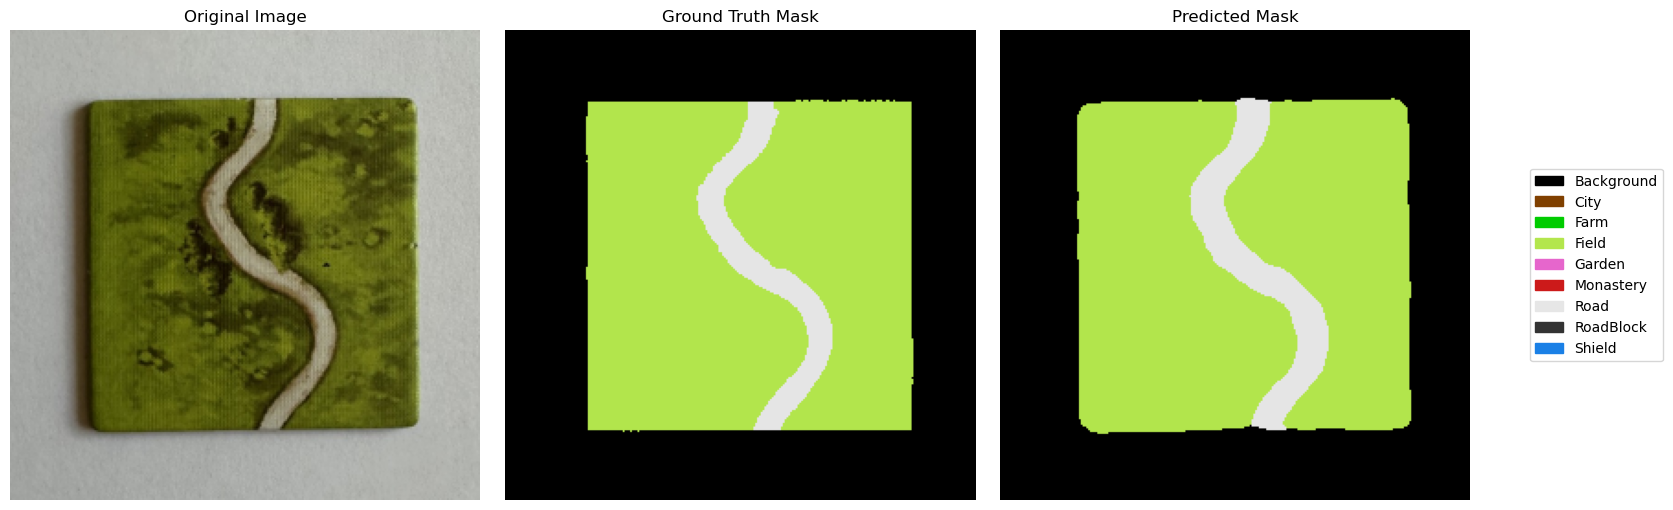

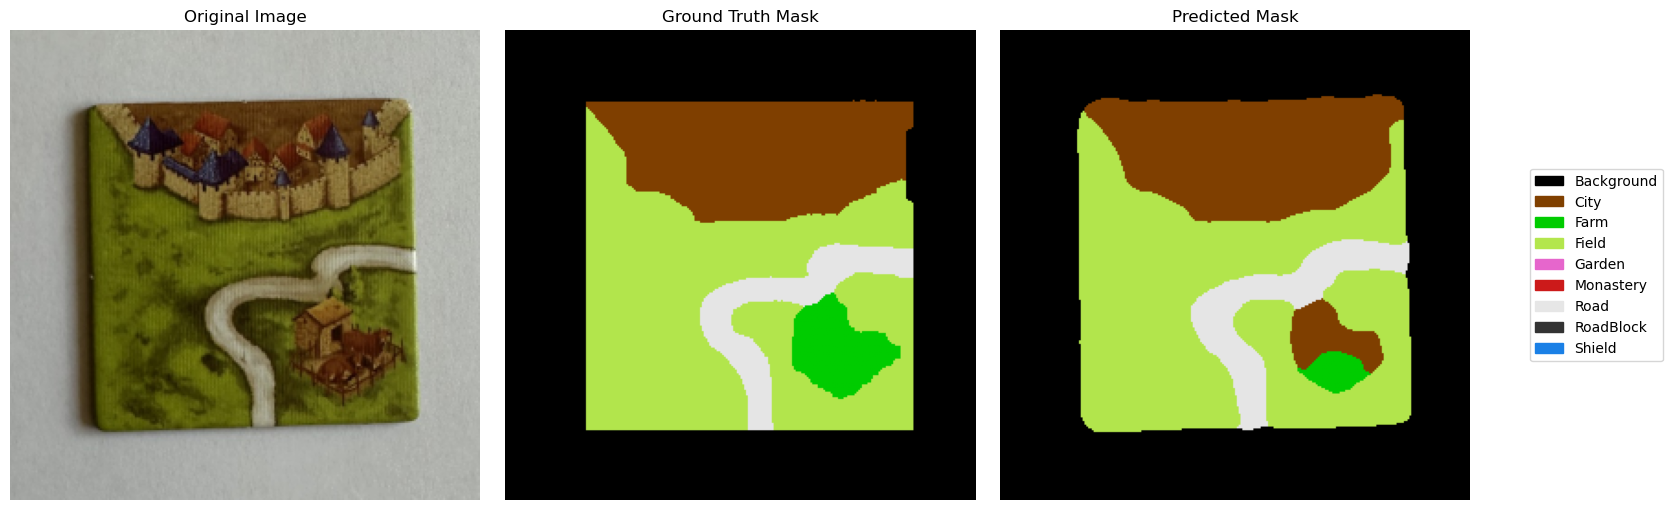

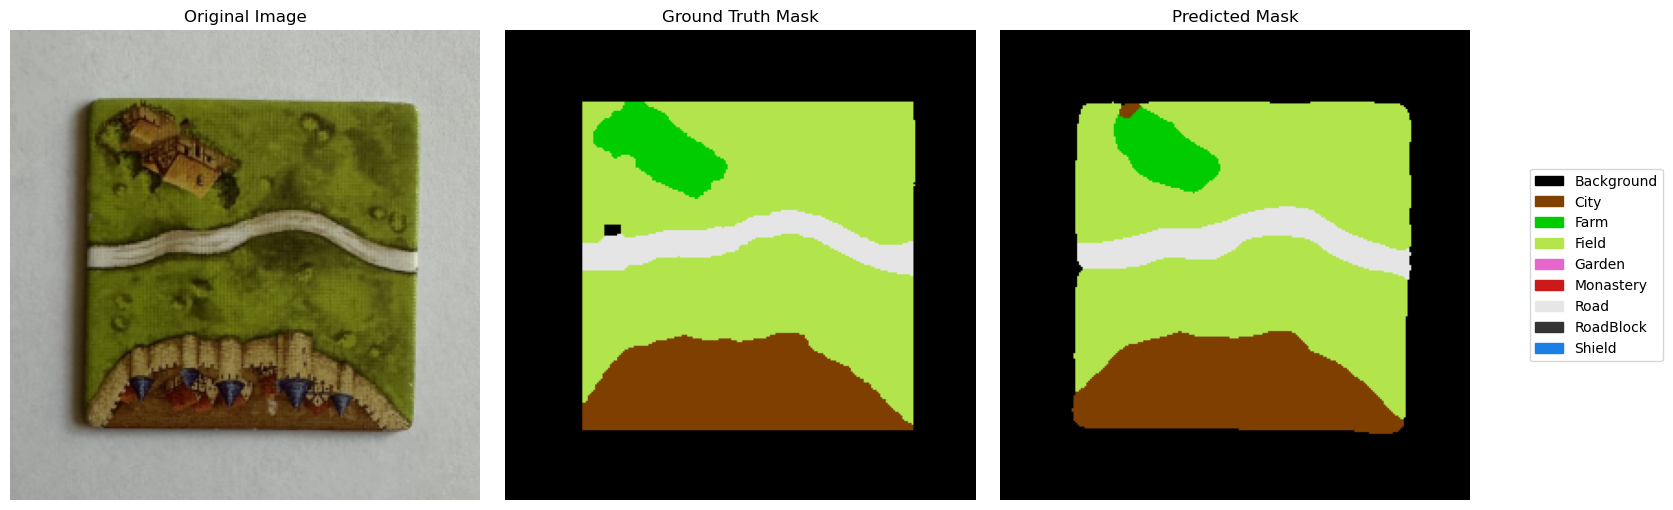

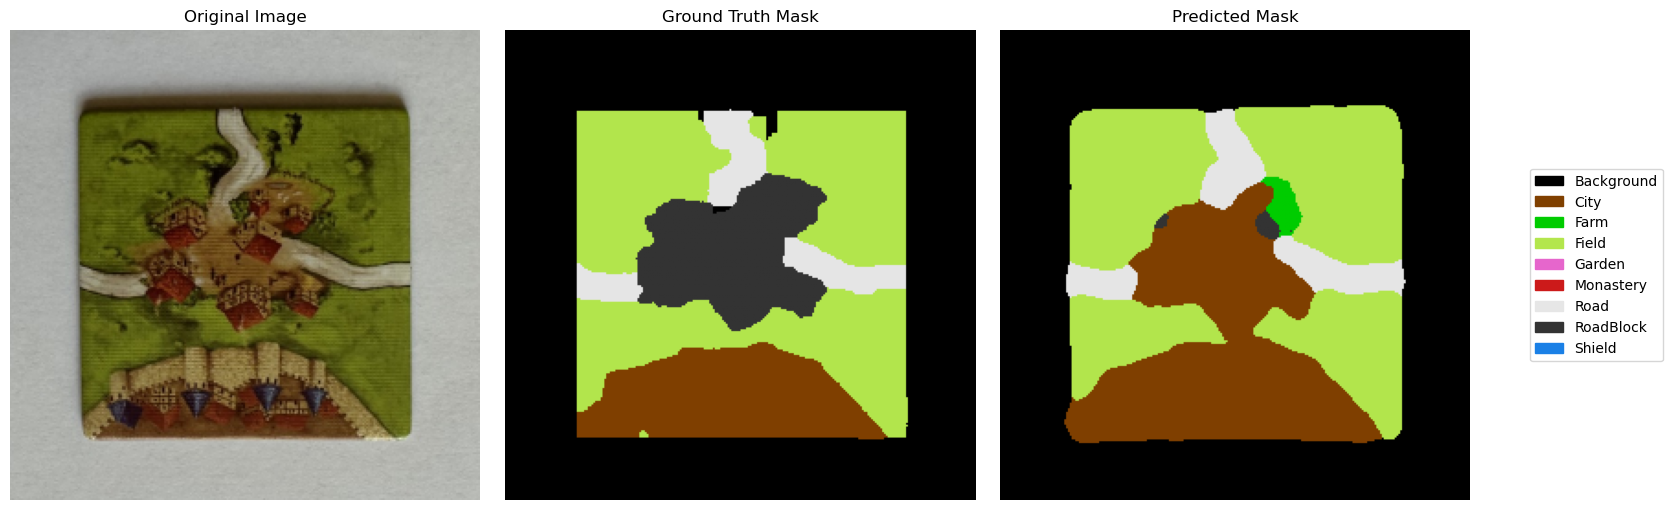

--- Train Set Predictions ---


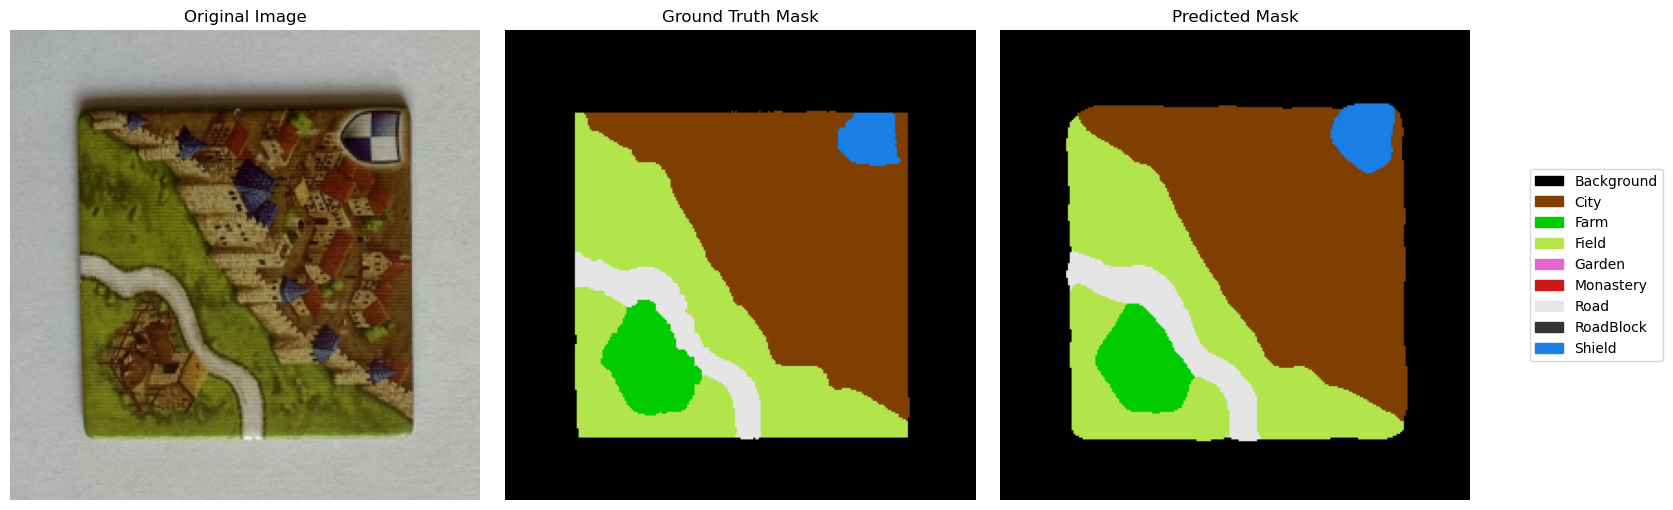

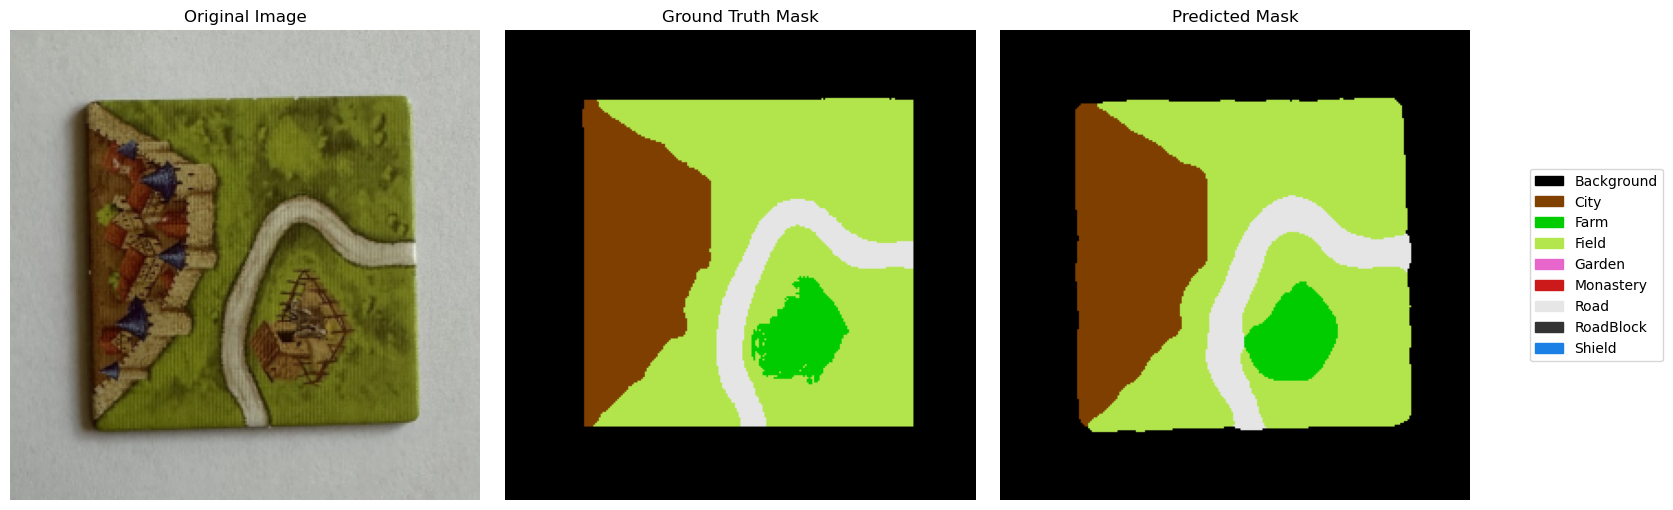

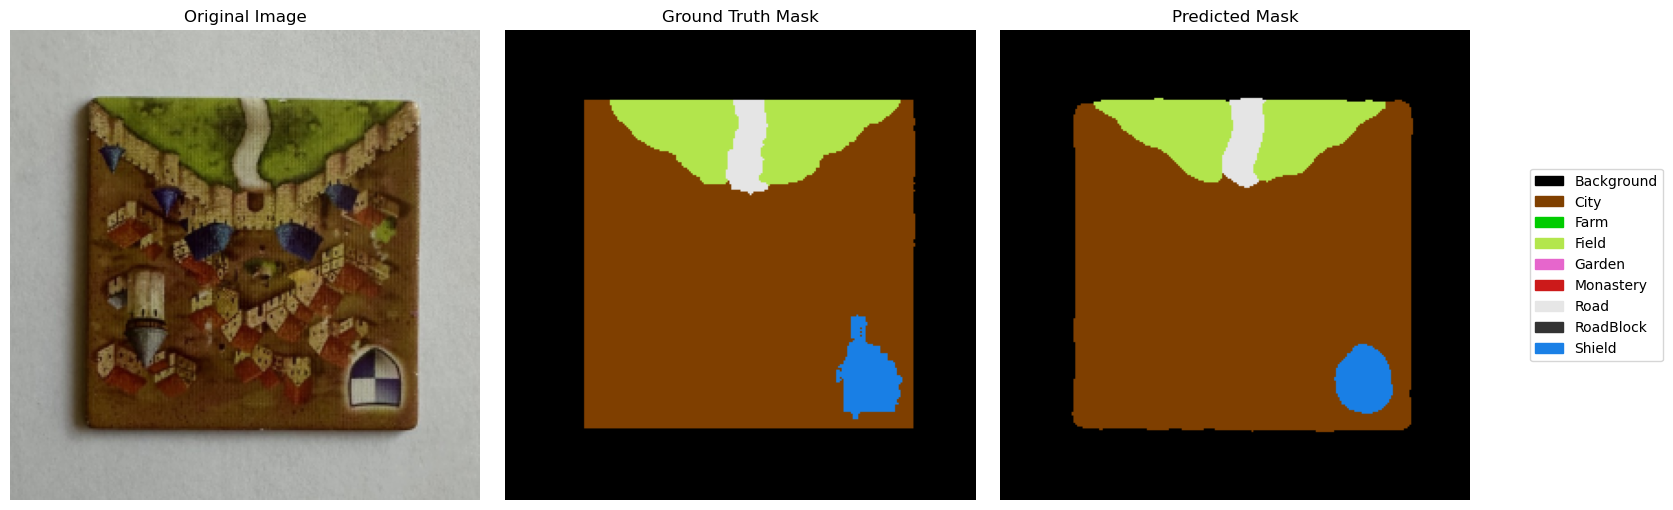

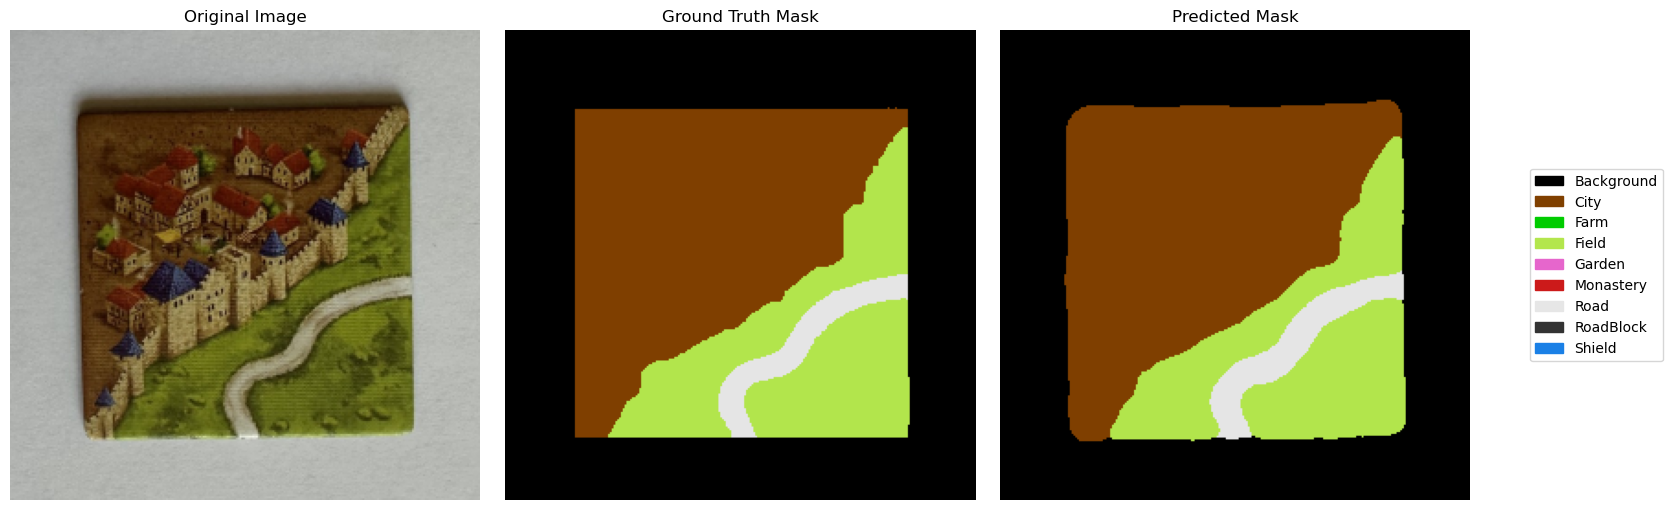

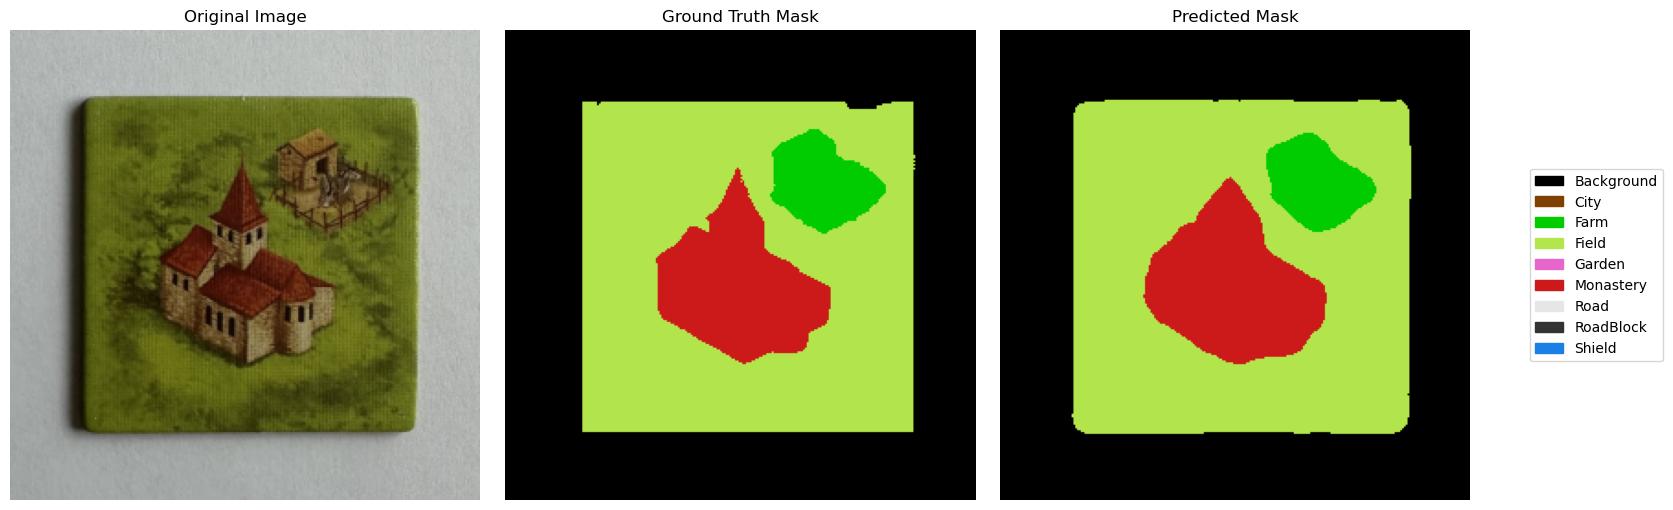

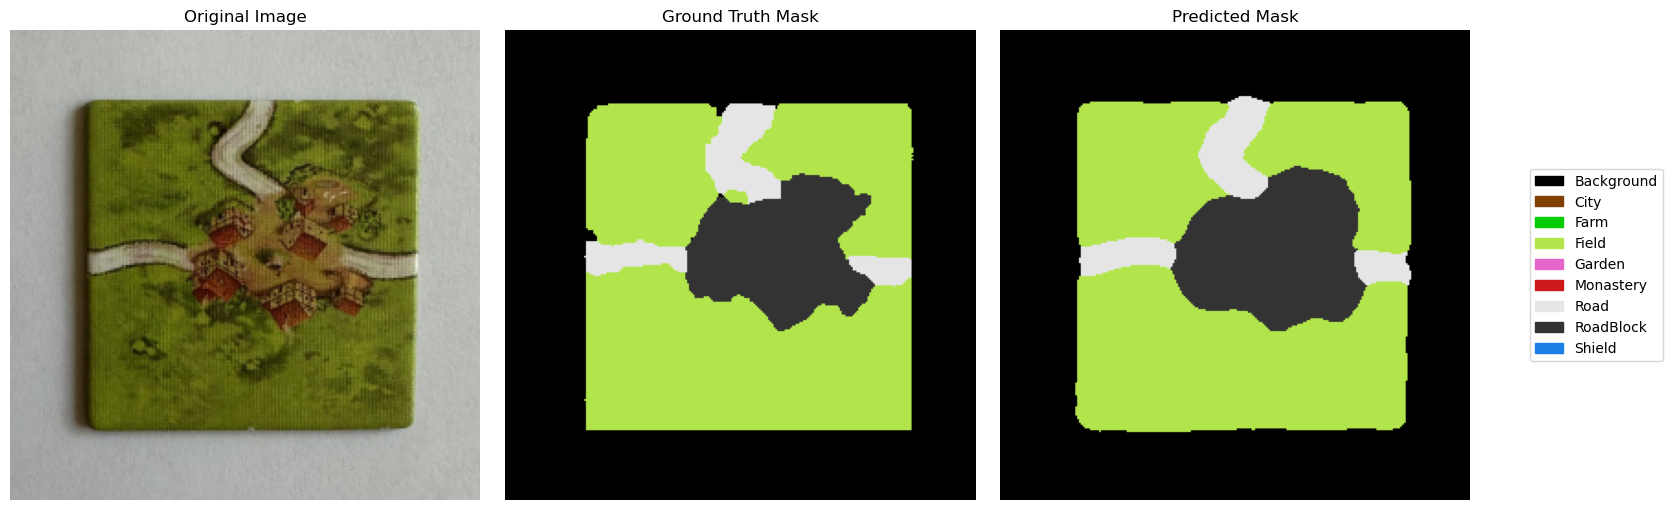

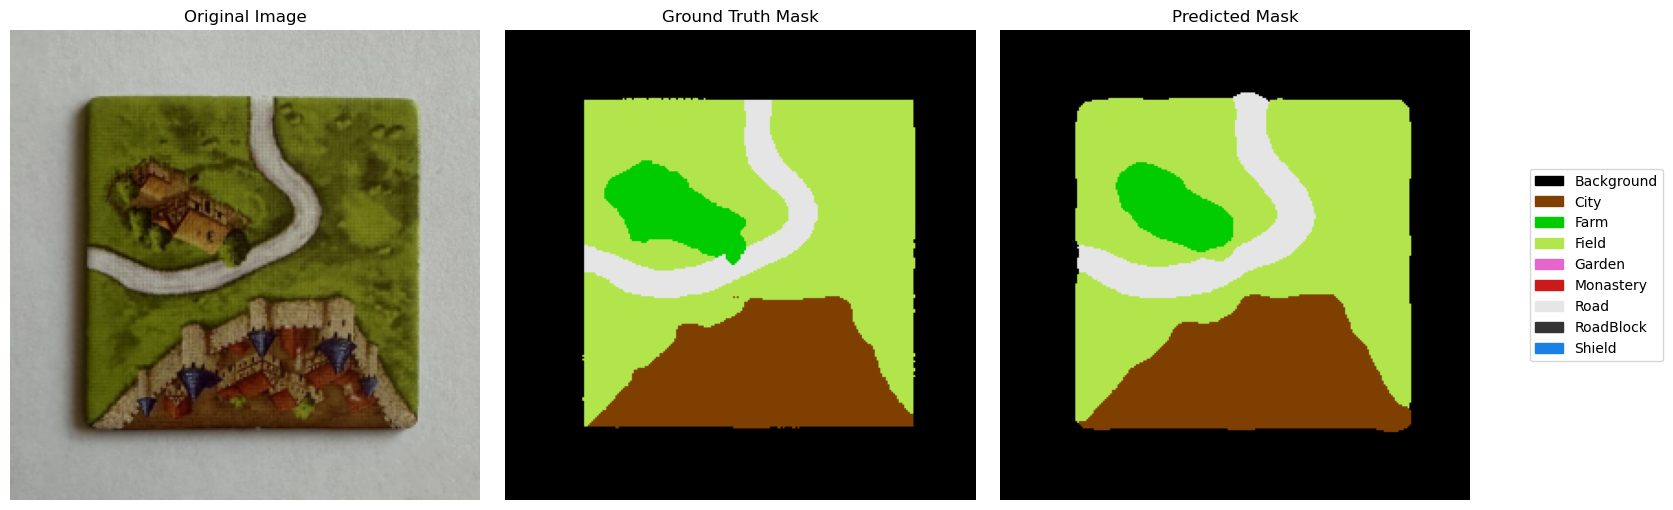

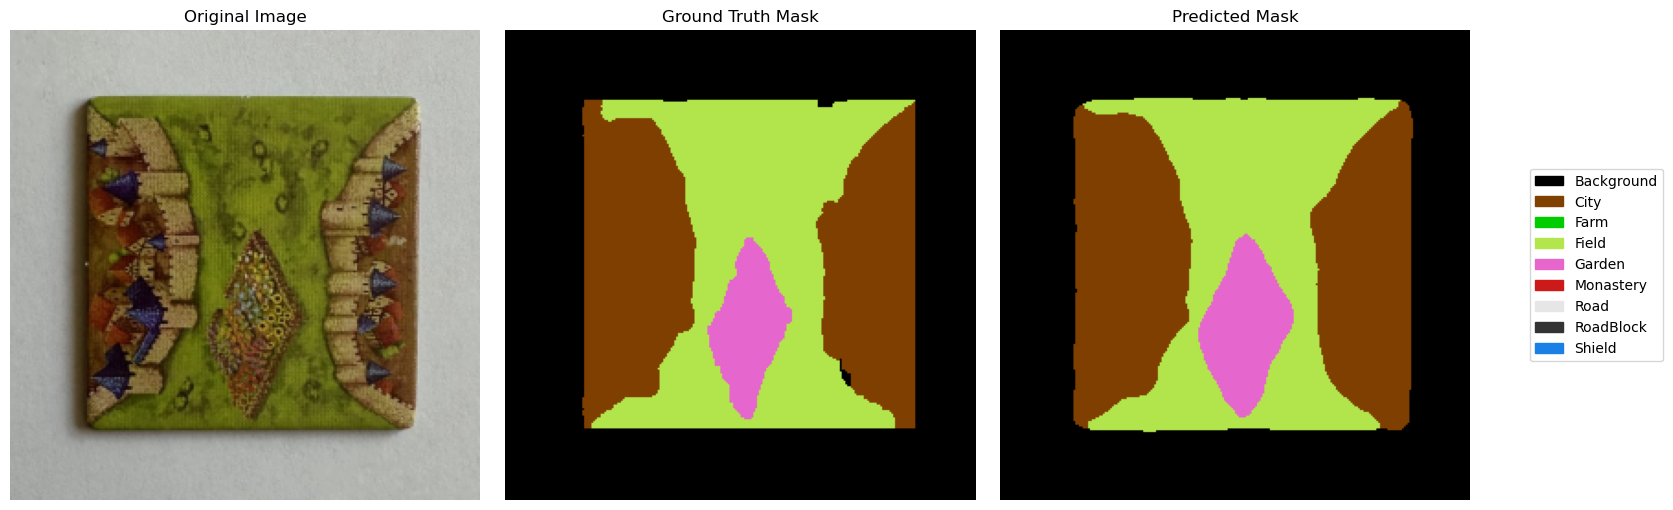

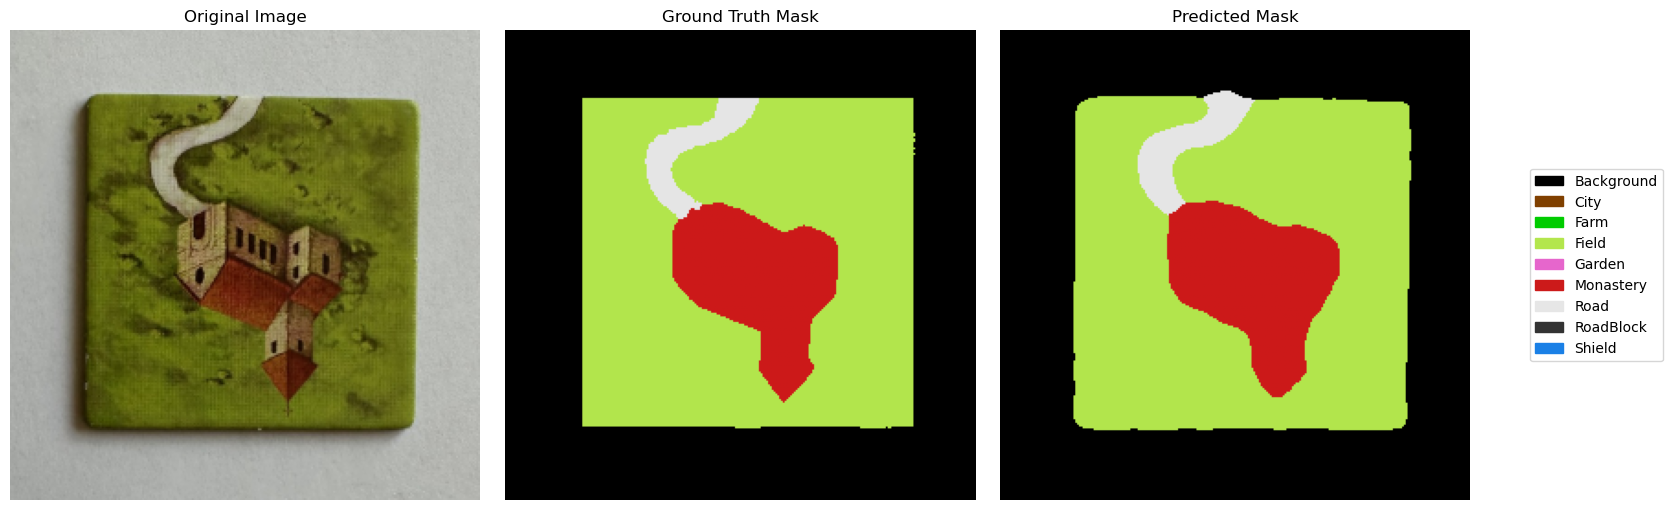

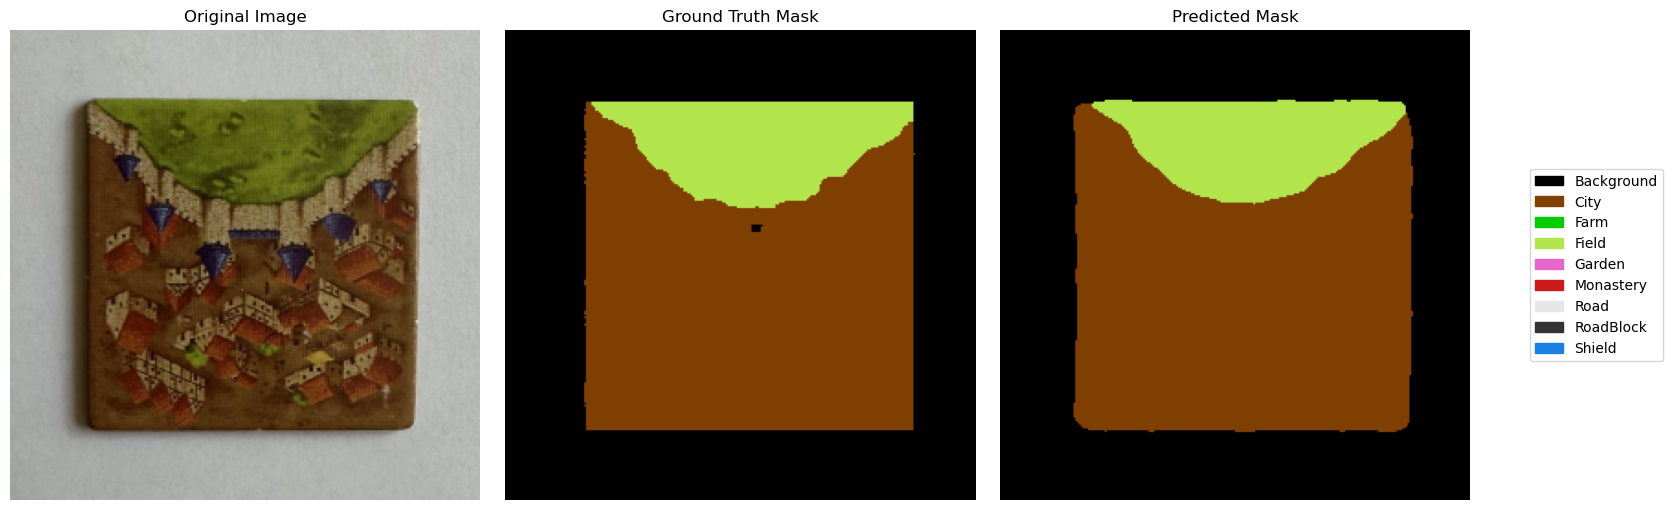

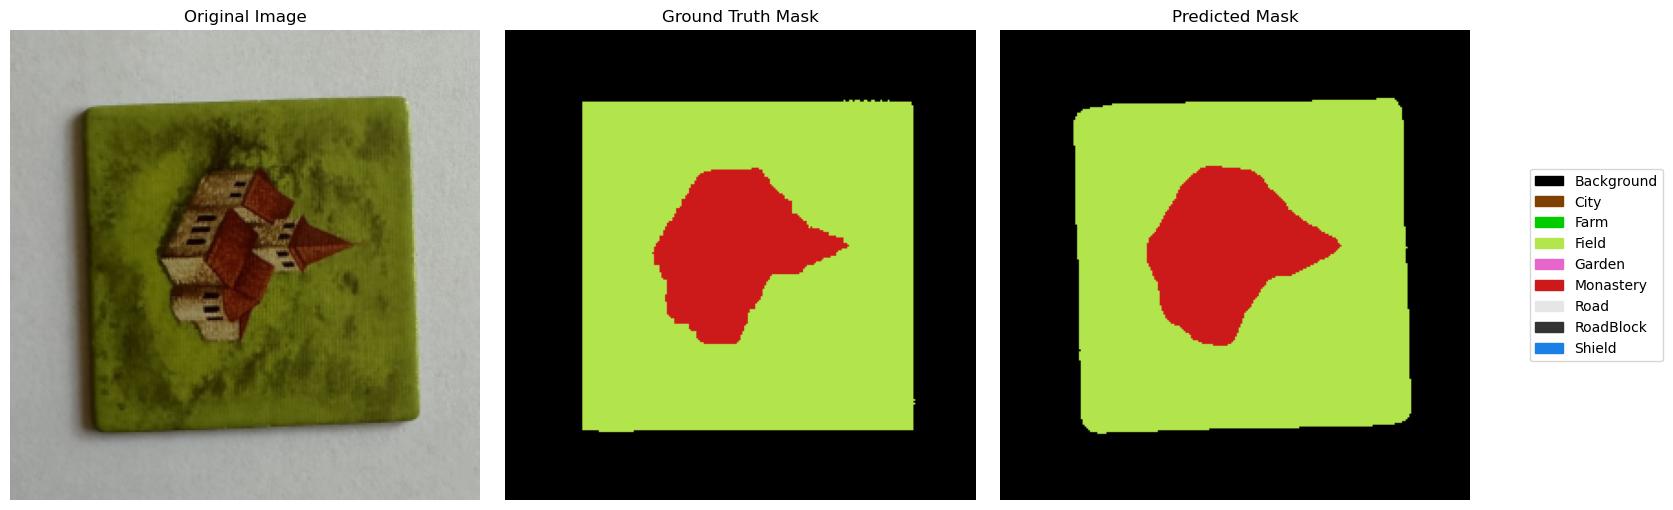

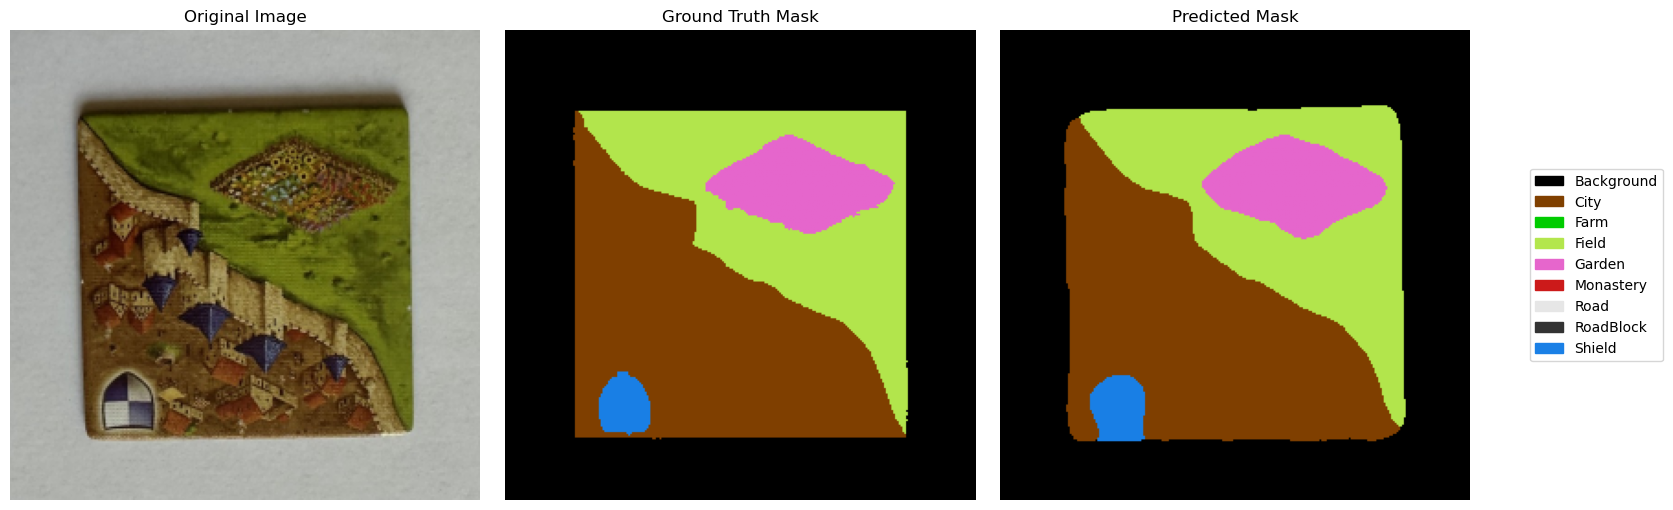

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import SegformerForSemanticSegmentation

# 1. Setup Label Mapping & Color Palette (9 Carcassonne Classes)
id2label = {
    0: "Background", 1: "City", 2: "Farm", 3: "Field", 
    4: "Garden", 5: "Monastery", 6: "Road", 7: "RoadBlock", 8: "Shield"
}

# Define a distinct color for each class (RGB normalized between 0 and 1)
CLASS_COLORS = np.array([
    [0.0, 0.0, 0.0],  # 0: Background (Black)
    [0.5, 0.25, 0.0], # 1: City (Brown)
    [0.0, 0.8, 0.0],  # 2: Farm (Bright Green)
    [0.7, 0.9, 0.3],  # 3: Field (Light Olive Green)
    [0.9, 0.4, 0.8],  # 4: Garden (Pink)
    [0.8, 0.1, 0.1],  # 5: Monastery (Red)
    [0.9, 0.9, 0.9],  # 6: Road (Light Gray/White)
    [0.2, 0.2, 0.2],  # 7: RoadBlock (Dark Gray)
    [0.1, 0.5, 0.9]   # 8: Shield (Blue)
])

def decode_mask_to_color(mask):
    """Converts a (H, W) class index map into an (H, W, 3) RGB image."""
    return CLASS_COLORS[mask]

def unnormalize_image(tensor_img):
    """Converts a normalized PyTorch tensor image back to printable numpy RGB (H, W, 3)."""
    img = tensor_img.cpu().numpy().transpose(1, 2, 0)
    # Undo typical PyTorch ImageNet normalization if applied:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    return np.clip(img, 0, 1)

# 2. Main Visualization Function
def visualize_predictions(model, data_loader, device, num_samples=5):
    """
    Plots Original Image, Ground Truth Mask, and Model Prediction side-by-side.
    """
    model.eval()
    samples_shown = 0

    # Create legend patches for output plot
    legend_patches = [
        mpatches.Patch(color=CLASS_COLORS[i], label=id2label[i])
        for i in range(len(id2label))
    ]

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            
            # Forward pass & resize outputs
            outputs = model(pixel_values=images)
            logits = outputs.logits
            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )
            
            # Get class predictions (Argmax over class dimension)
            preds = torch.argmax(upsampled_logits, dim=1)

            # Move to CPU for numpy processing
            images_cpu = images.cpu()
            masks_cpu = masks.cpu().numpy()
            preds_cpu = preds.cpu().numpy()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    return

                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                
                # 1. Original Image
                rgb_img = unnormalize_image(images_cpu[i])
                axes[0].imshow(rgb_img)
                axes[0].set_title("Original Image")
                axes[0].axis("off")

                # 2. Ground Truth Mask
                gt_color = decode_mask_to_color(masks_cpu[i])
                axes[1].imshow(gt_color)
                axes[1].set_title("Ground Truth Mask")
                axes[1].axis("off")

                # 3. Model Prediction
                pred_color = decode_mask_to_color(preds_cpu[i])
                axes[2].imshow(pred_color)
                axes[2].set_title("Predicted Mask")
                axes[2].axis("off")

                # Add shared legend to the plot
                fig.legend(handles=legend_patches, loc="center right", bbox_to_anchor=(1.12, 0.5))
                plt.tight_layout()
                plt.show()

                samples_shown += 1

# --- RUNNING THE INSPECTION ---
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load best saved weights into model architecture
    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/mit-b0",
        num_labels=9,
        id2label=id2label,
        label2id={v: k for k, v in id2label.items()},
        ignore_mismatched_sizes=True,
    )
    model.load_state_dict(torch.load("best_carcassonne_model.pth", map_location=device))
    model.to(device)

    # Inspect 3 validation samples
    print("--- Validation Set Predictions ---")
    visualize_predictions(model, val_loader, device, num_samples=4)

    # Inspect 3 test samples (replace 'test_loader' with your actual DataLoader variable)
    if 'train_loader' in globals():
        print("--- Train Set Predictions ---")
        visualize_predictions(model, train_loader, device, num_samples=12)

    # Inspect 3 test samples (replace 'test_loader' with your actual DataLoader variable)
    if 'test_loader' in globals():
        print("--- Test Set Predictions ---")
        visualize_predictions(model, test_loader, device, num_samples=3)